# Exporting Seabed Feature Polygons as GeoJSON

The analysis notebooks in this cookbook turn a bathymetry grid into vector
**feature polygons**: the Topographic Position Index notebook delineates highs and
lows from terrain curvature, and the openness and closeness notebook extracts plateaus
and canyons from how exposed each cell is to the sky. Both end with a
[GeoDataFrame](https://geopandas.org/) of polygons in the survey's projected
coordinate system.

A GeoDataFrame lives only inside a running Python session. To open these features in
desktop GIS software such as [QGIS](https://qgis.org/) or
[ArcGIS Pro](https://www.esri.com/en-us/arcgis/products/arcgis-pro/), or in
[Jupyter GIS](https://github.com/geojupyter/jupytergis), you need to write them to a
portable file on disk. This notebook covers that final step: loading the feature
polygons produced upstream, cleaning and standardizing them, and exporting
[GeoJSON](https://geojson.org/) that loads cleanly into any GIS.

## Overview

1. Where feature polygons come from and the on-disk convention this notebook expects.
2. Loading a feature layer with `geopandas` and inspecting its CRS and attributes.
3. Checking and repairing polygon geometries before export.
4. Recording feature area in metres before changing the coordinate system.
5. Reprojecting to WGS84, because the GeoJSON standard (RFC 7946) requires longitude/latitude.
6. Writing a standards-compliant GeoJSON file and validating the result.
7. A reusable export function, and notes on importing into QGIS, ArcGIS Pro, and Jupyter GIS.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [GeoPandas](https://geopandas.org/en/stable/getting_started/introduction.html) | Necessary | Feature polygons are stored in a GeoDataFrame |
| Coordinate reference systems | Necessary | We reproject between a projected CRS and WGS84 |
| {doc}`Topographic-Position-Index-Method` | Helpful | One source of the feature polygons |
| {doc}`openness_closeness_explainer` | Helpful | Another source of the feature polygons |
| {doc}`rasterviz-intro` | Helpful | Reading the bathymetry raster used by the stand-in data |

- **Time to learn**: 25 minutes

---

## Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import geopandas as gpd

# Used only to build the stand-in feature layer below
import rasterio as rio
import rasterio.features as rfeatures
from scipy.ndimage import convolve
from shapely.geometry import shape
from shapely.validation import make_valid

## Where the feature polygons come from

Each analysis notebook saves its mapped features to disk so that later steps, including
this one, can pick them up. The convention used here is a
[GeoPackage](https://www.geopackage.org/) file under `data/features/`, one file per
method, with a `feature_class` column separating highs from lows:

```
data/features/tpi_features.gpkg
data/features/openness_features.gpkg
```

GeoPackage is a good interchange format between analysis steps: it is a single file, it
preserves the full coordinate reference system and a typed attribute table, and it does
not round coordinates the way a text format would. We keep the data in its native
**projected** CRS at this stage so that area and distance stay in metres. The
reprojection to longitude/latitude happens only at the very end, when we write GeoJSON
for sharing.

```{note}
At the time of writing, the TPI and openness notebooks are still being finalized, so
their feature files may not exist yet. To keep this notebook self-contained and runnable
today, the next cell **generates a stand-in** `tpi_features.gpkg` directly from the
Gifford bathymetry. It is a placeholder for the real upstream output and uses a quick,
simplified terrain calculation, not the full TPI workflow. Once the analysis notebooks
write their own files, delete this one cell and the loading code below will pick up the
real data unchanged.
```

### Generating a stand-in feature layer (placeholder)

In [2]:
# PLACEHOLDER: stand-in for the feature polygons the TPI / openness notebooks will save.
# Delete this cell once data/features/tpi_features.gpkg is produced upstream.

features_dir = Path("../data/features")
features_dir.mkdir(parents=True, exist_ok=True)
tpi_gpkg = features_dir / "tpi_features.gpkg"

with rio.open("../data/gifford_bathy.tif") as dataset:
    bathy = dataset.read(1, masked=True).astype(float).filled(np.nan)
    transform = dataset.transform
    crs = dataset.crs


def quick_tpi(surface, radius_cells):
    """A fast, NaN-aware Topographic Position Index: each cell minus the mean of a
    circular neighbourhood. This stands in for the full TPI notebook computation."""
    y, x = np.ogrid[-radius_cells : radius_cells + 1, -radius_cells : radius_cells + 1]
    footprint = ((x**2 + y**2) <= radius_cells**2).astype(float)

    valid = np.isfinite(surface).astype(float)
    filled = np.where(np.isfinite(surface), surface, 0.0)
    neighbourhood_sum = convolve(filled, footprint, mode="nearest")
    neighbourhood_count = convolve(valid, footprint, mode="nearest")

    mean = np.divide(
        neighbourhood_sum,
        neighbourhood_count,
        out=np.full_like(neighbourhood_sum, np.nan),
        where=neighbourhood_count > 0,
    )
    tpi = surface - mean
    tpi[~np.isfinite(surface)] = np.nan
    return tpi


tpi = quick_tpi(bathy, radius_cells=25)
finite = np.isfinite(tpi)
threshold = 1.5 * np.nanstd(tpi)


def mask_to_polygons(mask, feature_class):
    """Vectorize a boolean mask into polygon records tagged with a feature class."""
    return [
        {"geometry": shape(geom), "feature_class": feature_class}
        for geom, value in rfeatures.shapes(
            mask.astype(np.uint8), mask=mask, transform=transform
        )
        if value == 1
    ]


records = mask_to_polygons(finite & (tpi > threshold), "high")
records += mask_to_polygons(finite & (tpi < -threshold), "low")

standin = gpd.GeoDataFrame(records, crs=crs)
standin["area_m2"] = standin.area
standin = standin[standin["area_m2"] > 250_000].reset_index(drop=True)
standin["feature_id"] = standin.index + 1
standin["method"] = "TPI"

standin.to_file(tpi_gpkg, layer="features", driver="GPKG")
print(f"Wrote {len(standin)} stand-in feature polygons to {tpi_gpkg}")

Wrote 116 stand-in feature polygons to ../data/features/tpi_features.gpkg


## Loading the feature polygons

From here on the notebook behaves as if the feature file already existed. We read it with
`geopandas.read_file`, which infers the format from the extension and restores the
geometry, attribute types, and coordinate reference system.

In [3]:
features = gpd.read_file("../data/features/tpi_features.gpkg")
features.head()

,feature_class,area_m2,feature_id,method,geometry
0,high,895000.0,1,TPI,"POLYGON ((534125 7066275, 534125 7066075, 5340..."
1,high,415000.0,2,TPI,"POLYGON ((528925 7062575, 528925 7062475, 5288..."
2,high,382500.0,3,TPI,"POLYGON ((539275 7062825, 539275 7062775, 5391..."
3,high,785000.0,4,TPI,"POLYGON ((545725 7062675, 545725 7062625, 5456..."
4,high,1265000.0,5,TPI,"POLYGON ((535025 7063875, 535025 7063725, 5349..."


The geometry column holds the polygons; the other columns are the attributes that
travel with each feature into the GIS. The coordinate reference system is read back from
the file rather than assumed.

In [4]:
print("Number of features :", len(features))
print("Geometry types     :", features.geom_type.unique().tolist())
print("CRS                 :", features.crs)
print("Attributes          :", [c for c in features.columns if c != "geometry"])
print("Feature classes     :", features["feature_class"].value_counts().to_dict())

Number of features : 116
Geometry types     : ['Polygon']
CRS                 : EPSG:32757
Attributes          : ['feature_class', 'area_m2', 'feature_id', 'method']
Feature classes     : {'low': 67, 'high': 49}


```{note}
The CRS here is a **projected** system (UTM, in metres), not longitude/latitude. That is
exactly what we want for measuring area, and it is what we will convert away from just
before writing GeoJSON.
```

## Checking and repairing geometries

Polygons produced by vectorizing a raster mask are usually clean, but a step that exports
data for others should never assume so. Self-intersections or "bowtie" rings make a
geometry **invalid**, and an invalid polygon can be silently dropped or mis-rendered by
GIS software. We check validity and repair anything that fails with `make_valid`, which
rebuilds a correct geometry without changing its extent.

In [5]:
invalid = ~features.geometry.is_valid
print("Invalid geometries :", int(invalid.sum()))

if invalid.any():
    features.loc[invalid, "geometry"] = features.loc[invalid, "geometry"].apply(make_valid)

# Drop any empty or missing geometries that would export as null features
features = features[~features.geometry.is_empty & features.geometry.notna()].copy()
print("Features after cleaning :", len(features))
print("All valid now           :", bool(features.geometry.is_valid.all()))

Invalid geometries : 0
Features after cleaning : 116
All valid now           : True


## Recording area before reprojecting

Feature area is one of the most useful attributes for downstream classification, and it
must be computed while the data is still in a projected CRS. Once we reproject to
longitude/latitude, `.area` returns square degrees, which is not a physical area and
varies with latitude. We therefore (re)compute `area_m2` now and store it as a column, so
the value is preserved in the exported file regardless of its coordinate system.

In [6]:
features["area_m2"] = features.area.round(1)
features[["feature_id", "feature_class", "method", "area_m2"]].head()

,feature_id,feature_class,method,area_m2
0,1,high,TPI,895000.0
1,2,high,TPI,415000.0
2,3,high,TPI,382500.0
3,4,high,TPI,785000.0
4,5,high,TPI,1265000.0


```{warning}
After the reprojection in the next step, calling `.area` on the GeoDataFrame would give
square degrees, not square metres. Always compute areas and lengths while the data is in
a projected CRS, and carry the result forward as an attribute.
```

## Reprojecting to WGS84

The GeoJSON standard, [RFC 7946](https://datatracker.ietf.org/doc/html/rfc7946),
mandates that coordinates be longitude and latitude on the WGS84 datum
([EPSG:4326](https://epsg.io/4326)). Writing GeoJSON in any other CRS is technically
out of spec and a common source of features landing in the wrong place when opened in a
web map or a tool that assumes lon/lat. We reproject with `to_crs` before writing.

In [7]:
features_wgs84 = features.to_crs(epsg=4326)
print("CRS after reprojection :", features_wgs84.crs.to_epsg())
print("Bounds (lon/lat)       :", [round(v, 4) for v in features_wgs84.total_bounds])

CRS after reprojection : 4326
Bounds (lon/lat)       : [np.float64(159.2219), np.float64(-26.8714), np.float64(159.6136), np.float64(-26.5032)]


## Writing the GeoJSON

`GeoDataFrame.to_file` with the `GeoJSON` driver writes the file. Two driver options make
the output a good citizen:

`RFC7946="YES"` enforces the standard: coordinates are written as longitude/latitude, the
polygon winding follows the right-hand rule, and the redundant `crs` member is omitted
(WGS84 is implied by the spec). `COORDINATE_PRECISION=6` rounds coordinates to six decimal
places, roughly 0.1 m at this latitude, which is finer than the 50 m bathymetry grid and
keeps the file small.

In [8]:
output_path = Path("../data/features/tpi_features.geojson")
features_wgs84.to_file(
    output_path,
    driver="GeoJSON",
    RFC7946="YES",
    COORDINATE_PRECISION=6,
)
print(f"Wrote {output_path} ({output_path.stat().st_size / 1024:.0f} KB)")

Wrote ../data/features/tpi_features.geojson (469 KB)


## Validating the output

A file is only useful if it is correct. We read the raw JSON back to confirm the
structure the standard expects: a top-level `FeatureCollection`, one feature per polygon,
and no `crs` member (which signals WGS84). Reloading it through GeoPandas confirms the
geometry and attributes survive a full round trip.

In [9]:
with open(output_path) as fh:
    geojson = json.load(fh)

print("Top-level type     :", geojson["type"])
print("Feature count      :", len(geojson["features"]))
print("Has 'crs' member   :", "crs" in geojson)  # False is correct for RFC 7946
print("First feature props:", geojson["features"][0]["properties"])

roundtrip = gpd.read_file(output_path)
print("Round-trip CRS     :", roundtrip.crs.to_epsg())
print("Round-trip columns :", [c for c in roundtrip.columns if c != "geometry"])

Top-level type     : FeatureCollection
Feature count      : 116
Has 'crs' member   : False
First feature props: {'feature_class': 'high', 'area_m2': 895000.0, 'feature_id': 1, 'method': 'TPI'}
Round-trip CRS     : 4326
Round-trip columns : ['feature_class', 'area_m2', 'feature_id', 'method']


## A quick map preview

Plotting the exported, reprojected features confirms they form sensible shapes in the
right place before we hand the file off. Highs and lows are drawn in different colors.

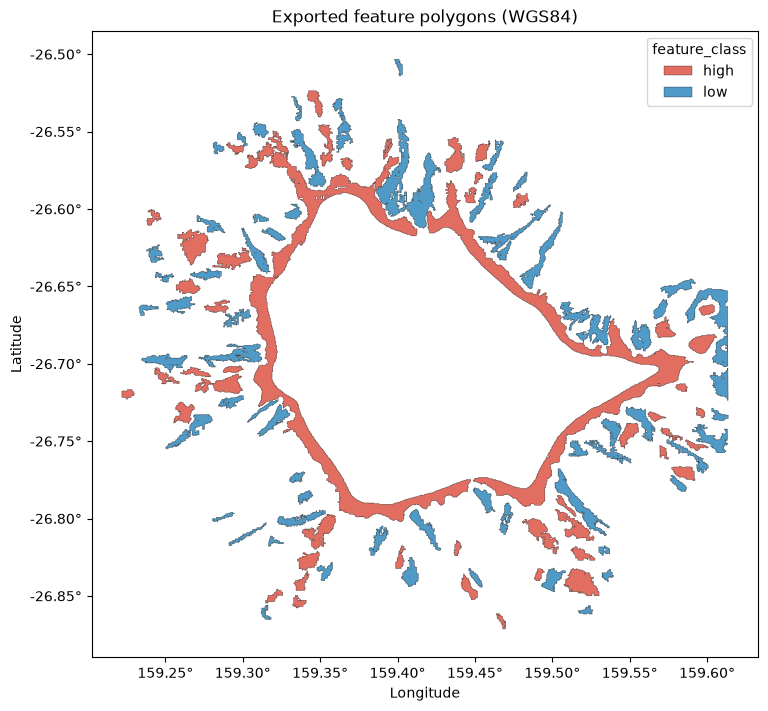

In [10]:
deg_formatter = mticker.FuncFormatter(lambda v, pos: f"{v:.2f}°")
colors = {"high": "#d7301f", "low": "#0570b0"}

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
for feature_class, group in features_wgs84.groupby("feature_class"):
    group.plot(
        ax=ax,
        facecolor=colors.get(feature_class, "gray"),
        edgecolor="black",
        linewidth=0.3,
        alpha=0.7,
        label=feature_class,
    )

ax.set_title("Exported feature polygons (WGS84)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.xaxis.set_major_formatter(deg_formatter)
ax.yaxis.set_major_formatter(deg_formatter)
ax.set_aspect("equal")
ax.legend(title="feature_class")
plt.show()

## A reusable export function

The same sequence applies to any feature layer: clean the geometries, record area in
metres, reproject, and write a standards-compliant GeoJSON. Wrapping it in one function
makes exporting the openness features, or any future layer, a single call.

In [11]:
def export_features_to_geojson(gdf, output_path, precision=6):
    """Clean, record metric area, reproject to WGS84, and write an RFC 7946 GeoJSON.

    The input GeoDataFrame must carry a projected CRS so that area is measured in metres.
    Returns the reprojected GeoDataFrame that was written.
    """
    gdf = gdf.copy()

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].apply(make_valid)
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()

    gdf["area_m2"] = gdf.area.round(1)

    gdf_wgs84 = gdf.to_crs(epsg=4326)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf_wgs84.to_file(
        output_path,
        driver="GeoJSON",
        RFC7946="YES",
        COORDINATE_PRECISION=precision,
    )
    return gdf_wgs84


# Example: re-export the same features through the helper
_ = export_features_to_geojson(features, "../data/features/tpi_features.geojson")
print("Re-exported via export_features_to_geojson")

Re-exported via export_features_to_geojson


## Using the GeoJSON in GIS

The file `data/features/tpi_features.geojson` is now ready to open anywhere.

In **QGIS**, drag the file onto the map canvas, or use *Layer > Add Layer > Add Vector
Layer*. The `feature_class`, `area_m2`, and `method` columns appear in the attribute
table and can drive styling and filtering.

In **ArcGIS Pro**, add it with *Map > Add Data*, or use the *JSON To Features* geoprocessing
tool to convert it into a feature class inside a geodatabase.

In **Jupyter GIS**, you can load the file into a `GISDocument` and view it on an
interactive map directly in JupyterLab, alongside other layers. The cell below builds
the document and displays it.

In [12]:
from jupytergis import GISDocument

doc = GISDocument()
doc.add_geojson_layer(
    path="../data/features/tpi_features.geojson",
    name="TPI features",
)
doc

```{tip}
GeoJSON is ideal for sharing and web use, but it stores everything as text and a single
geometry type per file. For heavier analysis, or to keep several layers and their styling
together, export a **GeoPackage** instead: `features.to_file("features.gpkg",
driver="GPKG")`. Keep that copy in the projected CRS so areas and distances stay in
metres.
```

## Summary

Feature polygons produced by the analysis notebooks live in a projected coordinate system
inside a GeoDataFrame. To use them outside Python we write them to disk. This notebook
loaded a feature layer, repaired any invalid geometries, recorded each feature's area in
square metres while the data was still projected, reprojected to WGS84 as the GeoJSON
standard requires, and wrote an RFC 7946 GeoJSON file. Validating the file confirmed it is
a `FeatureCollection` in longitude/latitude with the attributes intact, and the
`export_features_to_geojson` helper packages the whole sequence for reuse. The result
opens directly in QGIS, ArcGIS Pro, and Jupyter GIS.

### What's next?

With features exported to a portable format, they can be styled, filtered, and combined
with other datasets in a full GIS, or carried into the classification step that assigns
each polygon a geomorphic feature type.

## Resources and References

- GeoJSON standard, RFC 7946: https://datatracker.ietf.org/doc/html/rfc7946
- GeoPandas, writing files: https://geopandas.org/en/stable/docs/user_guide/io.html
- GeoPackage format: https://www.geopackage.org/
- pyogrio, the I/O engine GeoPandas uses: https://pyogrio.readthedocs.io/
- QGIS documentation: https://docs.qgis.org/
- Jupyter GIS: https://github.com/geojupyter/jupytergis